In [ ]:
pip install pandas

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings("ignore")

In [2]:
ticker = "TCS.NS"
df = yf.download (ticker, start = "2026-02-12", end = "2026-08-12", auto_adjust = False)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,,
2026-02-12,2698.514160,2750.100098,2880.000000,2740.000000,2869.800049,10612156
2026-02-13,2641.700195,2692.199951,2713.000000,2585.000000,2585.000000,11168735
2026-02-16,2655.830322,2706.600098,2719.800049,2671.000000,2700.000000,2918730
2026-02-17,2666.427490,2717.399902,2760.000000,2695.199951,2716.000000,4209118
2026-02-18,2644.349609,2694.899902,2730.000000,2657.300049,2730.000000,2950820


In [3]:
df.shape

(124, 6)

In [4]:
df.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
count,124.000000,124.000000,124.000000,124.000000,124.000000,1.240000e+02
mean,2336.748215,2365.455636,2396.940312,2339.789527,2368.936290,4.552408e+06
std,169.593970,182.652673,184.870194,180.784166,184.649549,2.761469e+06
min,1971.788818,1982.599976,2052.000000,1976.800049,2008.000000,0.000000e+00
25%,2210.233459,2222.525024,2252.325073,2200.924988,2214.250000,2.905300e+06
50%,2348.750366,2391.150024,2420.800049,2365.150024,2386.000000,3.791848e+06
75%,2454.524963,2473.899902,2504.924927,2451.174988,2488.474976,5.206208e+06
max,2698.514160,2750.100098,2880.000000,2740.000000,2869.800049,1.633158e+07


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 124 entries, 2026-02-12 to 2026-08-11
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Adj Close, TCS.NS)  124 non-null    float64
 1   (Close, TCS.NS)      124 non-null    float64
 2   (High, TCS.NS)       124 non-null    float64
 3   (Low, TCS.NS)        124 non-null    float64
 4   (Open, TCS.NS)       124 non-null    float64
 5   (Volume, TCS.NS)     124 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 6.8 KB


In [6]:
df = df.dropna()

In [7]:
df.isnull().sum()

Price      Ticker
Adj Close  TCS.NS    0
Close      TCS.NS    0
High       TCS.NS    0
Low        TCS.NS    0
Open       TCS.NS    0
Volume     TCS.NS    0
dtype: int64

In [8]:
if isinstance(df.columns, pd.MultiIndex):
    close_data = df["Close"].iloc[:, 0]
else:
    close_data = df["Close"]
close_data = close_data.dropna()
print(close_data.head())

Date
2026-02-12    2750.100098
2026-02-13    2692.199951
2026-02-16    2706.600098
2026-02-17    2717.399902
2026-02-18    2694.899902
Name: TCS.NS, dtype: float64


In [9]:
df = pd.DataFrame({"Close": close_data})
df.head()

,Close
Date,
2026-02-12,2750.100098
2026-02-13,2692.199951
2026-02-16,2706.600098
2026-02-17,2717.399902
2026-02-18,2694.899902


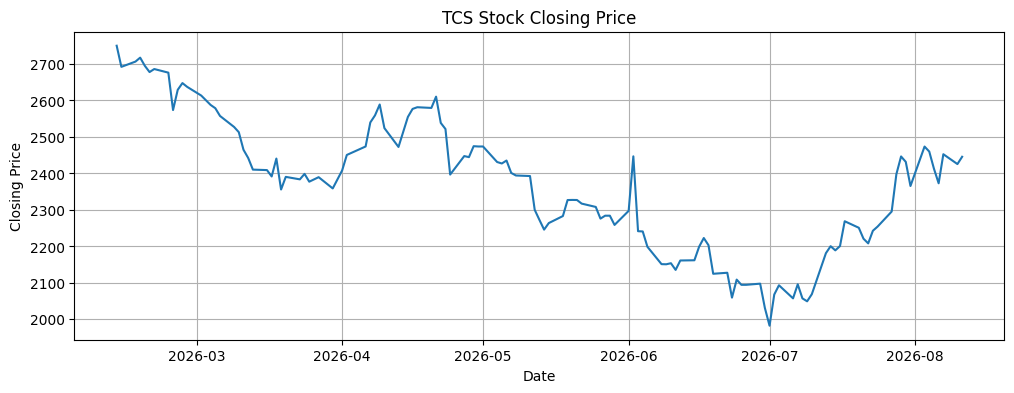

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["Close"])
plt.title("TCS Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

In [11]:
df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()

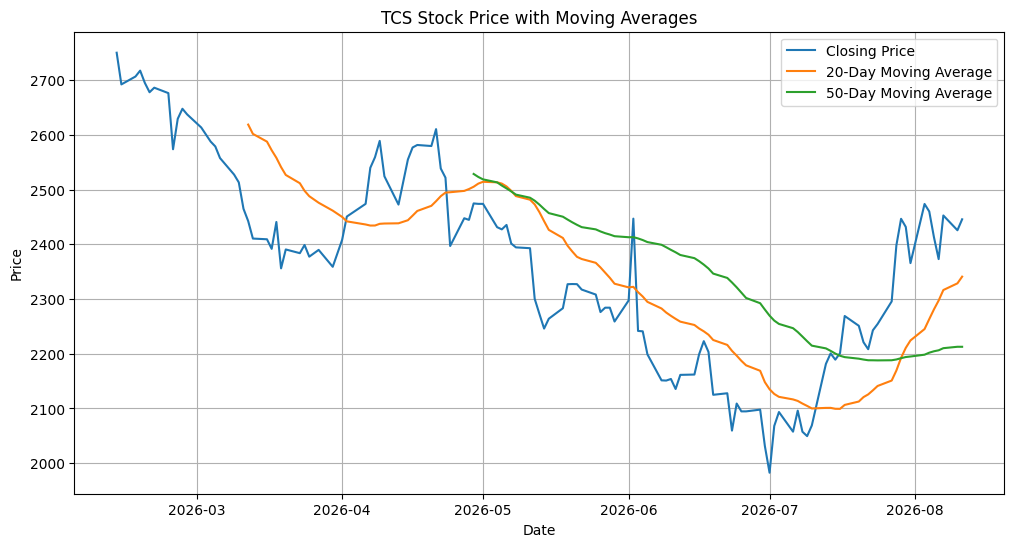

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Close"], label="Closing Price")
plt.plot(df.index, df["MA20"], label="20-Day Moving Average")
plt.plot(df.index, df["MA50"], label="50-Day Moving Average")
plt.title("TCS Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
df["Daily_Return"] = df["Close"].pct_change()
df.head()

,Close,MA20,MA50,Daily_Return
Date,,,,
2026-02-12,2750.100098,NaN,NaN,NaN
2026-02-13,2692.199951,NaN,NaN,-0.021054
2026-02-16,2706.600098,NaN,NaN,0.005349
2026-02-17,2717.399902,NaN,NaN,0.003990
2026-02-18,2694.899902,NaN,NaN,-0.008280


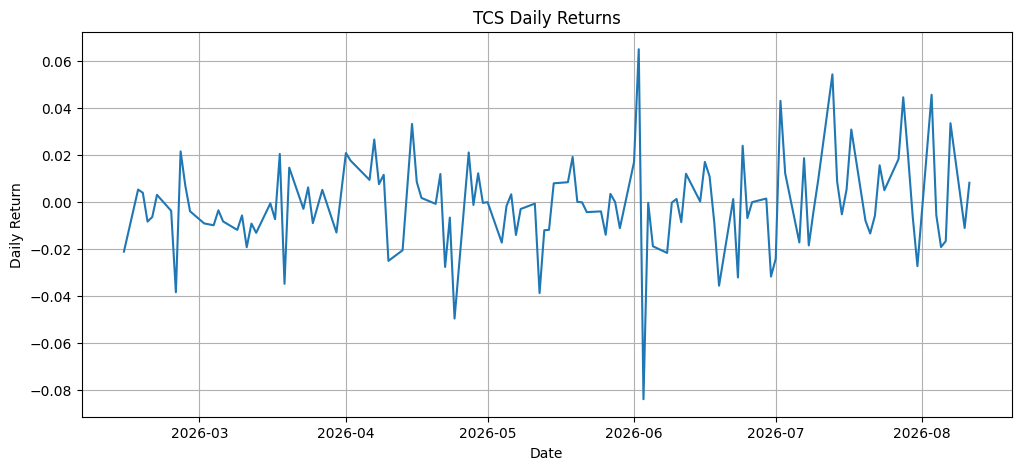

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Daily_Return"])
plt.title("TCS Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

In [15]:
prices = df["Close"].values.reshape(-1, 1)
print("Total observations:", len(prices))

Total observations: 124


In [16]:
train_size = int(len(prices) * 0.80)
train_data = prices[:train_size]
test_data = prices[train_size:]
print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))

Training observations: 99
Testing observations: 25


Train ARIMA Model

In [17]:
arima_model = ARIMA(train_data.flatten(), order = (5, 1, 0))
arima_result = arima_model.fit()
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   99
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -512.325
Date:                Mon, 24 Aug 2026   AIC                           1036.650
Time:                        19:58:27   BIC                           1052.159
Sample:                             0   HQIC                          1042.923
                                 - 99                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1691      0.076     -2.226      0.026      -0.318      -0.020
ar.L2          0.0054      0.107      0.050      0.960      -0.205       0.216
ar.L3          0.0041      0.135      0.030      0.9

In [18]:
arima_predictions = arima_result.forecast(steps=len(test_data))
arima_predictions = np.array(arima_predictions)
print(arima_predictions[:10])

[2093.20971292 2078.73570305 2078.98082953 2082.75901968 2075.996032
 2078.33363923 2080.23883661 2079.67789948 2079.51340168 2080.52229136]


In [19]:
arima_mae = mean_absolute_error(test_data.flatten(),arima_predictions)
arima_mse = np.sqrt(mean_squared_error(test_data.flatten(),arima_predictions))
arima_mape = np.mean(np.abs((test_data.flatten() - arima_predictions)/ test_data.flatten())) * 100
print("ARIMA Results")
print("-------------------------")
print("MAE  :", arima_mae)
print("MSE :", arima_mse)
print("MAPE :", arima_mape, "%")

ARIMA Results
-------------------------
MAE  : 220.8582886194795
MSE : 252.217663586939
MAPE : 9.348156981776802 %


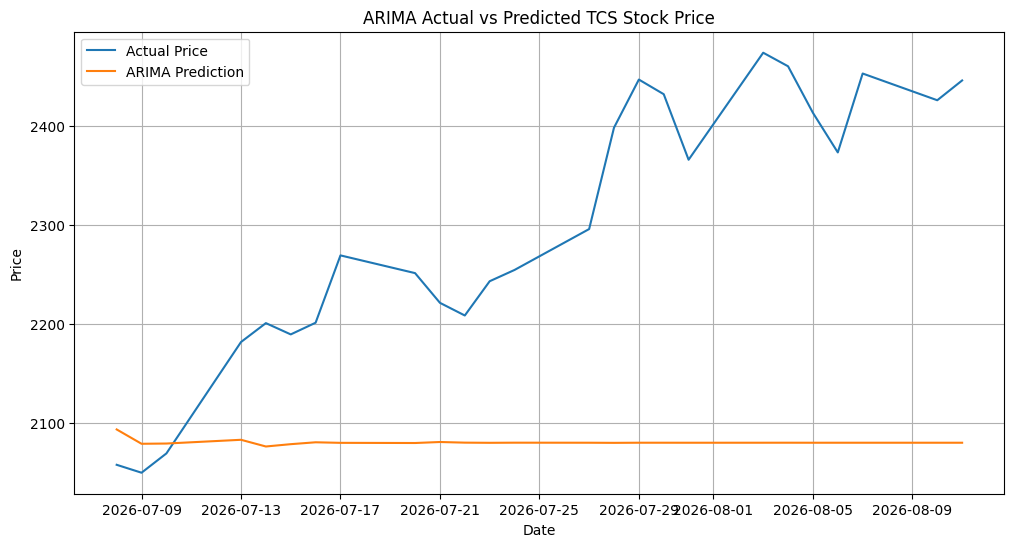

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(df.index[train_size:], test_data.flatten(), label="Actual Price")
plt.plot(df.index[train_size:], arima_predictions, label="ARIMA Prediction")
plt.title("ARIMA Actual vs Predicted TCS Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

LSTM model

In [21]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)
print(scaled_prices[:5])

[[1.        ]
 [0.92456008]
 [0.94332248]
 [0.95739389]
 [0.92807793]]


In [22]:
look_back = 6
X = []
y = []
for i in range(look_back, len(scaled_prices)):
    X.append(scaled_prices[i-look_back:i, 0])
    y.append(scaled_prices[i, 0])
X = np.array(X)
y = np.array(y)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (118, 6)
y shape: (118,)


In [23]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
print("Final X shape:", X.shape)

Final X shape: (118, 6, 1)


In [24]:
lstm_train_size = int(len(X) * 0.80)
X_train = X[:lstm_train_size]
X_test = X[lstm_train_size:]
y_train = y[:lstm_train_size]
y_test = y[lstm_train_size:]
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (94, 6, 1)
X_test : (24, 6, 1)
y_train: (94,)
y_test : (24,)


In [25]:
lstm_model = Sequential()
lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=50, return_sequences=False))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(25))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer="adam", loss="mean_squared_error")
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 6, 50)               │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 6, 50)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = lstm_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test) ,verbose=1)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 464ms/step - loss: 0.2412 - val_loss: 0.1147
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.1250 - val_loss: 0.0511
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0504 - val_loss: 0.0123
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0222 - val_loss: 0.0111
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0378 - val_loss: 0.0143
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0333 - val_loss: 0.0080
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0210 - val_loss: 0.0089
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0176 - val_loss: 0.0141
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0200 - val_loss: 0.0167
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0196 - val_loss: 0.0150
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0165 - val_loss: 0.0116
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0154 - val_loss: 0.0087


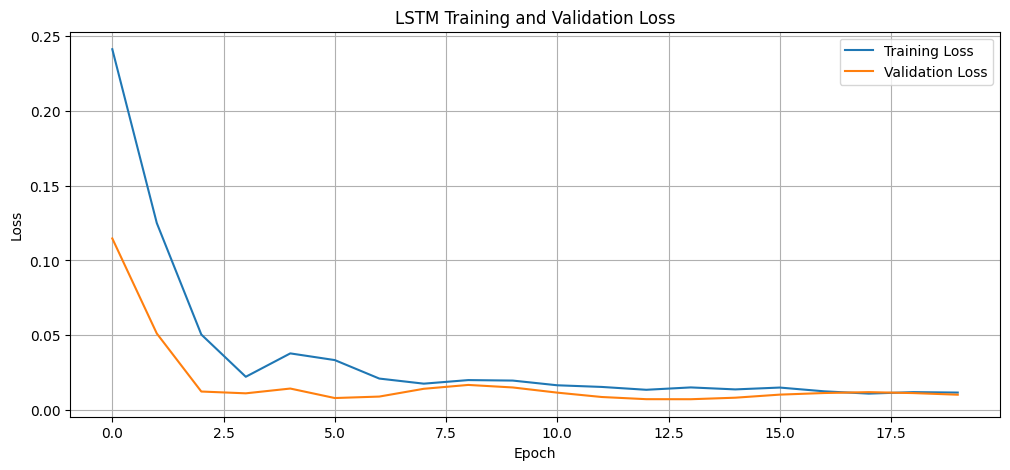

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
lstm_predictions = lstm_model.predict(X_test)
print(lstm_predictions[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[[0.17110738]
 [0.18599837]
 [0.18506837]
 [0.18872996]
 [0.20708804]]


In [29]:
lstm_predictions = scaler.inverse_transform(lstm_predictions)
actual_lstm = scaler.inverse_transform(y_test.reshape(-1, 1))

In [38]:
lstm_mae = mean_absolute_error(actual_lstm, lstm_predictions)
lstm_mse = np.sqrt(mean_squared_error(actual_lstm, lstm_predictions))
lstm_mape = np.mean(np.abs((actual_lstm.flatten() - lstm_predictions.flatten()) / actual_lstm.flatten())) * 100
print("LSTM Results")
print("--------------------------")
print("MAE  :", lstm_mae)
print("MSE :", lstm_mse)
print("MAPE :", lstm_mape,"%")

LSTM Results
--------------------------
MAE  : 2304.5949458312243
MSE : 2307.9480208307104
MAPE : 99.98463745157355 %


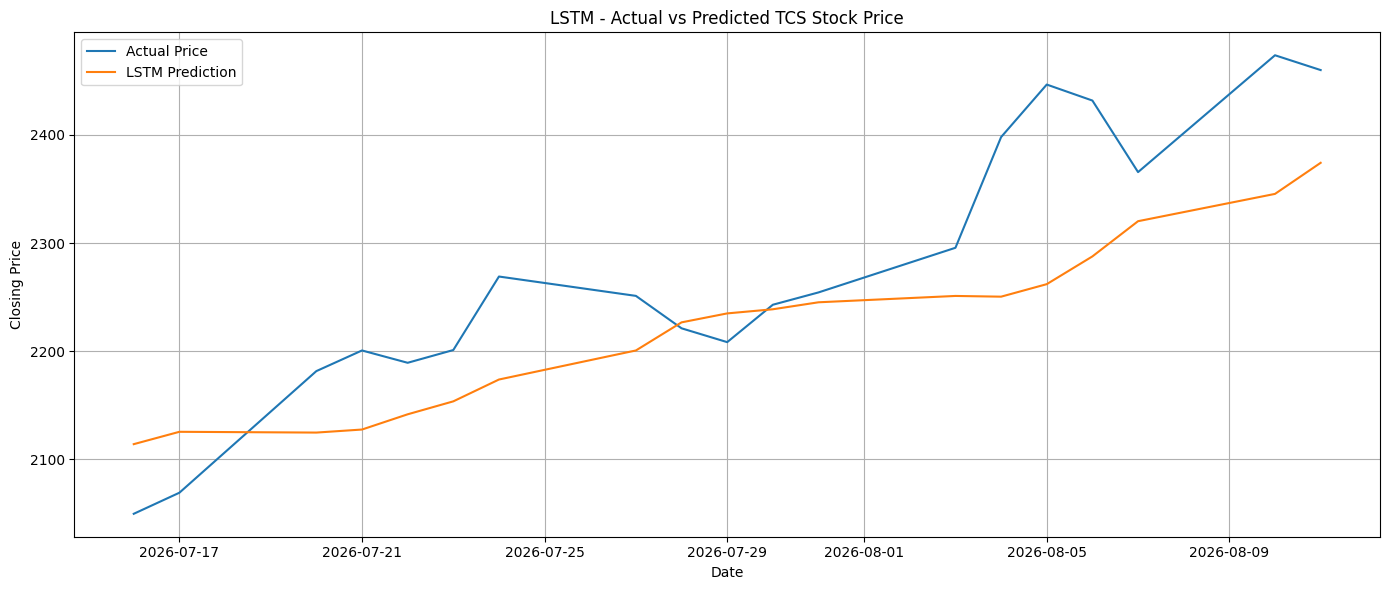

In [31]:
lstm_test_dates = df.index[train_size + look_back:]
min_length = min(len(lstm_test_dates), len(actual_lstm), len(lstm_predictions))
lstm_test_dates = lstm_test_dates[:min_length]
actual_prices = actual_lstm.flatten()[:min_length]
predicted_prices = lstm_predictions.flatten()[:min_length]
plt.figure(figsize=(14, 6))
plt.plot(lstm_test_dates, actual_prices, label="Actual Price")
plt.plot(lstm_test_dates, predicted_prices, label="LSTM Prediction")
plt.title("LSTM - Actual vs Predicted TCS Stock Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "LSTM"],
    "MAE": [arima_mae, lstm_mae],
    "MSE": [arima_mse, lstm_mse],
    "MAPE": [arima_mape, lstm_mape]})
comparison

,Model,MAE,MSE,MAPE
0,ARIMA,220.858289,252.217664,9.348157
1,LSTM,61.953766,77.475163,2.656496


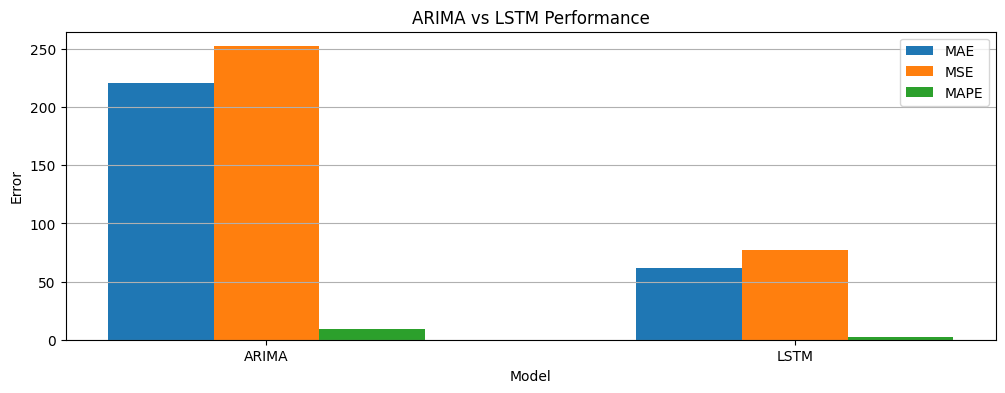

In [33]:
plt.figure(figsize=(12, 4))
x = np.arange(len(comparison["Model"]))
plt.bar(x - 0.2, comparison["MAE"], width=0.2, label="MAE")
plt.bar(x, comparison["MSE"], width=0.2, label="MSE")
plt.bar(x + 0.2, comparison["MAPE"], width=0.2, label="MAPE")
plt.xticks(x, comparison["Model"])
plt.title("ARIMA vs LSTM Performance")
plt.xlabel("Model")
plt.ylabel("Error")
plt.legend()
plt.grid(axis="y")
plt.show()

In [39]:
last_60_days = scaled_prices[-look_back:]
X_future = last_60_days.reshape(1, look_back, 1)
next_day_scaled = lstm_model.predict(X_future)
next_day_price = scaler.inverse_transform(next_day_scaled)
print("Predicted Next Trading Day Closing Price:", float(next_day_price[0][0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Predicted Next Trading Day Closing Price: 2399.421875


In [35]:
final_arima = ARIMA(prices.flatten(), order=(5, 1, 0))
final_arima_result = final_arima.fit()
next_day_arima = final_arima_result.forecast(steps=1)
print("ARIMA Predicted Next Trading Day Closing Price:", float(next_day_arima[0]))

ARIMA Predicted Next Trading Day Closing Price: 2447.31404173656


In [36]:
final_predictions = pd.DataFrame({"Model": ["ARIMA", "LSTM"], "Next_Day_Predicted_Price":[float(next_day_arima[0]), float(next_day_price[0][0])]})
final_predictions

,Model,Next_Day_Predicted_Price
0,ARIMA,2447.314042
1,LSTM,2399.421875


save the models

In [50]:
import joblib
joblib.dump(arima_result, "arima_tcs.pkl")
print("ARIMA model saved successfully")

ARIMA model saved successfully


In [56]:
lstm_model.save("lstm_tcs.keras")
print("LSTM model saved successfully")

LSTM model saved successfully


In [62]:
joblib.dump(scaler, "tcs_scaler.pkl")
print("minMax sacler saved sucessfully")

minMax sacler saved sucessfully
